In [1]:
# ==============================================================
# CELLA 1 — Setup e caricamento dati
# ==============================================================
 
%matplotlib inline
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t as student_t, levy_stable
import warnings
warnings.filterwarnings("ignore")
 
sp = pd.read_csv("../data/dailytotalreturn_S&P.csv")
sp["DlyCalDt"] = pd.to_datetime(sp["DlyCalDt"])
sp = sp.sort_values("DlyCalDt").reset_index(drop=True)
r = sp["DlyTotRet"].dropna().values
 
print(f"Osservazioni: {len(r)}")
print(f"Periodo: {sp['DlyCalDt'].min().date()} → {sp['DlyCalDt'].max().date()}")
print("Dati caricati correttamente ✓")
 
 
# ==============================================================
# CELLA 2 — Fitting Normale
# ==============================================================
 
mu_n, sigma_n = norm.fit(r)
print(f"Normale:  μ = {mu_n:.6f},  σ = {sigma_n:.6f}")

Osservazioni: 8817
Periodo: 1990-01-02 → 2024-12-31
Dati caricati correttamente ✓
Normale:  μ = 0.000466,  σ = 0.011329


In [2]:
# ==============================================================
# CELLA 3 — Fitting t di Student
# ==============================================================
 
df_t, loc_t, scale_t = student_t.fit(r, floc=0)
var_t = scale_t**2 * df_t / (df_t - 2)
print(f"t-Student:  ν = {df_t:.4f},  μ = {loc_t:.6f},  σ_t = {scale_t:.6f}")
print(f"            → std implicita = {np.sqrt(var_t):.6f}")
if df_t < 4:
    print(f"            → kurtosis INFINITA (ν = {df_t:.4f} < 4): code estremamente pesanti")
elif df_t < 6:
    print(f"            → kurtosis molto elevata (ν = {df_t:.4f} tra 4 e 6)")

t-Student:  ν = 2.8781,  μ = 0.000000,  σ_t = 0.006881
            → std implicita = 0.012457
            → kurtosis INFINITA (ν = 2.8781 < 4): code estremamente pesanti


In [3]:
# ==============================================================
# CELLA 4 — Fitting Stable di Lévy (MLE completo, ~20-30 min)
# Lascia girare — la barra di progresso conferma che lavora
# ==============================================================

import time
from IPython.display import display, clear_output

print("Fitting Stable di Lévy via MLE numerico...")
print("Tempo stimato: 20-30 minuti. Non interrompere.")
print("─" * 50)

start = time.time()
alpha_s, beta_s, loc_s, scale_s = levy_stable.fit(r, method="mle")
elapsed = time.time() - start

print(f"✓ Completato in {elapsed/60:.1f} minuti")
print(f"\nStable (MLE):")
print(f"  α = {alpha_s:.4f}  (indice stabilità: 2=normale, <2=code pesanti)")
print(f"  β = {beta_s:.4f}  (asimmetria: 0=simmetrica)")
print(f"  μ = {loc_s:.6f}  (posizione)")
print(f"  σ = {scale_s:.6f}  (scala)")

if alpha_s < 2:
    print(f"\n→ varianza INFINITA (α = {alpha_s:.4f} < 2)")
    print(f"→ conferma la critica di Mandelbrot alla std come misura di rischio")

Fitting Stable di Lévy via MLE numerico...
Tempo stimato: 20-30 minuti. Non interrompere.
──────────────────────────────────────────────────
✓ Completato in 117.3 minuti

Stable (MLE):
  α = 1.5692  (indice stabilità: 2=normale, <2=code pesanti)
  β = -0.1323  (asimmetria: 0=simmetrica)
  μ = 0.000318  (posizione)
  σ = 0.005611  (scala)

→ varianza INFINITA (α = 1.5692 < 2)
→ conferma la critica di Mandelbrot alla std come misura di rischio


In [4]:
# CELLA 5 — AIC e BIC
# ==============================================================
 
def aic_bic(logL, k, n):
    return -2*logL + 2*k, -2*logL + k*np.log(n)
 
n = len(r)
 
ll_n = np.sum(norm.logpdf(r, mu_n, sigma_n))
ll_t = np.sum(student_t.logpdf(r, df_t, loc_t, scale_t))
ll_s = np.sum(levy_stable.logpdf(r, alpha_s, beta_s, loc_s, scale_s))
 
aic_n, bic_n = aic_bic(ll_n, 2, n)
aic_t, bic_t = aic_bic(ll_t, 3, n)
aic_s, bic_s = aic_bic(ll_s, 4, n)
 
best_aic = min(aic_n, aic_t, aic_s)
 
print(f"{'Distribuzione':<14} {'LogL':>10} {'AIC':>10} {'BIC':>10} {'ΔAIC':>8}")
print("-"*50)
print(f"{'Normale':<14} {ll_n:>10.1f} {aic_n:>10.1f} {bic_n:>10.1f} {aic_n-best_aic:>8.1f}")
print(f"{'t-Student':<14} {ll_t:>10.1f} {aic_t:>10.1f} {bic_t:>10.1f} {aic_t-best_aic:>8.1f}")
print(f"{'Stable':<14} {ll_s:>10.1f} {aic_s:>10.1f} {bic_s:>10.1f} {aic_s-best_aic:>8.1f}")
 
nomi = {aic_n: "Normale", aic_t: "t-Student", aic_s: "Stable"}
print(f"\n→ Modello migliore per AIC: {nomi[best_aic]}")

Distribuzione        LogL        AIC        BIC     ΔAIC
--------------------------------------------------
Normale           26992.4   -53980.8   -53966.7   2264.0
t-Student         28125.4   -56244.9   -56223.6      0.0
Stable            28092.7   -56177.4   -56149.0     67.5

→ Modello migliore per AIC: t-Student


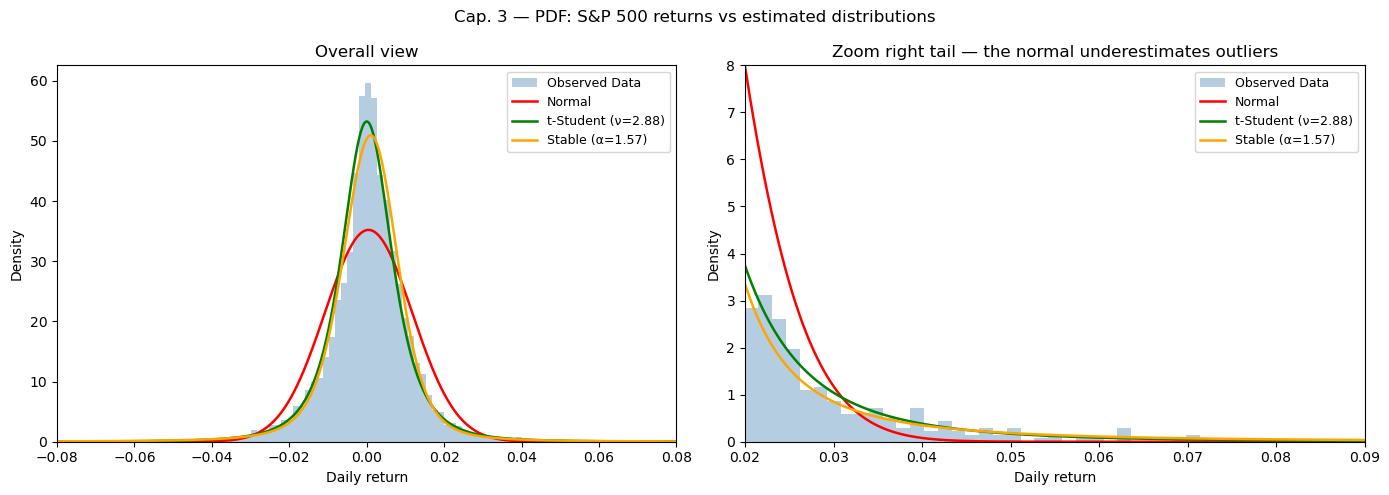

Grafico salvato: cap3_pdf.png


In [5]:
# ==============================================================
# CELLA 6 — Grafico PDF confronto
# ==============================================================
 
x = np.linspace(-0.10, 0.10, 1000)
 
pdf_n = norm.pdf(x, mu_n, sigma_n)
pdf_t = student_t.pdf(x, df_t, loc_t, scale_t)
pdf_s = levy_stable.pdf(x, alpha_s, beta_s, loc_s, scale_s)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cap. 3 — PDF: S&P 500 returns vs estimated distributions", fontsize=12)
 
# Pannello sinistro: visione d'insieme
ax = axes[0]
ax.hist(r, bins=150, density=True, color="steelblue", alpha=0.4, label="Observed Data")
ax.plot(x, pdf_n, "r-",      lw=1.8, label="Normal")
ax.plot(x, pdf_t, "g-",      lw=1.8, label=f"t-Student (ν={df_t:.2f})")
ax.plot(x, pdf_s, color="orange", lw=1.8, label=f"Stable (α={alpha_s:.2f})")
ax.set_xlim(-0.08, 0.08)
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
ax.set_title("Overall view")
ax.legend(fontsize=9)
 
# Pannello destro: zoom coda destra
ax = axes[1]
ax.hist(r, bins=150, density=True, color="steelblue", alpha=0.4, label="Observed Data")
ax.plot(x, pdf_n, "r-",      lw=1.8, label="Normal")
ax.plot(x, pdf_t, "g-",      lw=1.8, label=f"t-Student (ν={df_t:.2f})")
ax.plot(x, pdf_s, color="orange", lw=1.8, label=f"Stable (α={alpha_s:.2f})")
ax.set_xlim(0.02, 0.09)
ax.set_ylim(0, 8)
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
ax.set_title("Zoom right tail — the normal underestimates outliers")
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("cap3_pdf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: cap3_pdf.png")
 

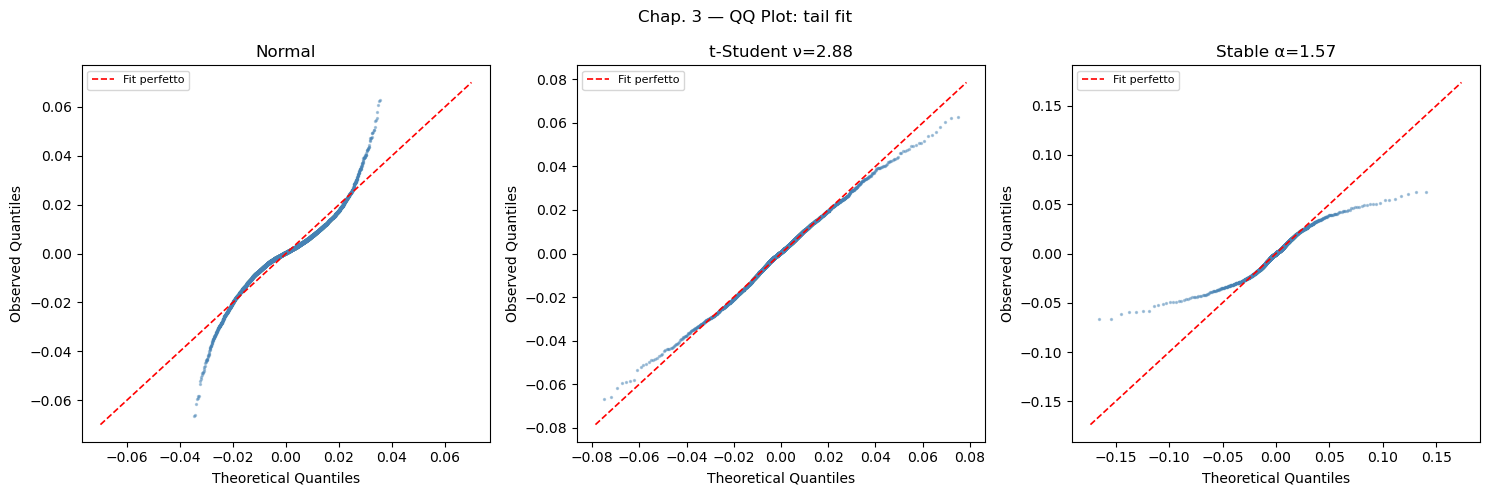

Grafico salvato: cap3_qqplot.png


In [6]:
# ==============================================================
# CELLA 7 — QQ plot per le 3 distribuzioni
# ==============================================================
 
probs = np.linspace(0.001, 0.999, len(r))
q_obs = np.quantile(r, probs)
 
distribuzioni = [
    ("Normal",                norm(mu_n, sigma_n)),
    (f"t-Student ν={df_t:.2f}", student_t(df_t, loc_t, scale_t)),
    (f"Stable α={alpha_s:.2f}", levy_stable(alpha_s, beta_s, loc_s, scale_s)),
]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Chap. 3 — QQ Plot: tail fit", fontsize=12)
 
for ax, (nome, dist) in zip(axes, distribuzioni):
    q_th = dist.ppf(probs)
    ax.scatter(q_th, q_obs, s=2, alpha=0.4, color="steelblue")
    lim = max(abs(q_obs).max(), abs(q_th).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.2, label="Fit perfetto")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Observed Quantiles")
    ax.set_title(nome)
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("cap3_qqplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: cap3_qqplot.png")

In [7]:
# ==============================================================
# CELLA 8 — Analisi delle code (tail analysis)
# ==============================================================
 
print(f"{'Soglia':<8} {'Empirico':>10} {'Normale':>10} {'t-Student':>10} {'Moltiplicatore N':>18}")
print("-"*58)
 
for k in [2, 3, 4, 5]:
    p_emp  = np.mean(np.abs(r - mu_n) > k * sigma_n)
    p_norm = 2 * (1 - norm.cdf(k))
    p_t    = 2 * (1 - student_t.cdf(k, df_t, loc_t, scale_t))
    mult   = p_emp / p_norm
    print(f">{k}σ    {p_emp:>10.6f} {p_norm:>10.6f} {p_t:>10.6f} {mult:>18.1f}x")
 
print("\nIl moltiplicatore mostra quante volte più frequenti sono gli eventi")
print("estremi rispetto alle previsioni della normale.")

Soglia     Empirico    Normale  t-Student   Moltiplicatore N
----------------------------------------------------------
>2σ      0.049450   0.045500   0.000000                1.1x
>3σ      0.015538   0.002700   0.000000                5.8x
>4σ      0.006351   0.000063   0.000000              100.3x
>5σ      0.003289   0.000001   0.000000             5737.1x

Il moltiplicatore mostra quante volte più frequenti sono gli eventi
estremi rispetto alle previsioni della normale.


In [8]:
# ==============================================================
# CELLA 9 — Tabella riassuntiva
# ==============================================================
 
risultati = pd.DataFrame({
    "Distribuzione": ["Normale", f"t-Student (ν={df_t:.2f})", f"Stable (α={alpha_s:.2f})"],
    "Parametri":     [2, 3, 4],
    "Log-Likelihood":[round(ll_n,1), round(ll_t,1), round(ll_s,1)],
    "AIC":           [round(aic_n,1), round(aic_t,1), round(aic_s,1)],
    "BIC":           [round(bic_n,1), round(bic_t,1), round(bic_s,1)],
    "ΔAIC":          [round(aic_n-best_aic,1), round(aic_t-best_aic,1), round(aic_s-best_aic,1)],
})
 
print(risultati.to_string(index=False))
risultati.to_csv("cap3_risultati.csv", index=False)
print("\nSalvato: cap3_risultati.csv")

     Distribuzione  Parametri  Log-Likelihood      AIC      BIC   ΔAIC
           Normale          2         26992.4 -53980.8 -53966.7 2264.0
t-Student (ν=2.88)          3         28125.4 -56244.9 -56223.6    0.0
   Stable (α=1.57)          4         28092.7 -56177.4 -56149.0   67.5

Salvato: cap3_risultati.csv
